# EDA

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import seaborn as sns
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("EDA") \
    .config("spark.ui.port", "0") \
    .getOrCreate()

## Features:
* ``age``
* ``ppg`` - Points per game
* ``fg_avg ``- Field goal percentage
* ``three_pt_avg`` - 3 Point percentege
* ``ft_avg`` - Freethrow percentage
* ``apg`` - Assists per game
* ``rpg`` - Rebounds per game
* ``spg`` - Steals per game
* ``bpg`` - Blocks per game
* ``mpg ``-  Minutes per game (full game - 48 minutes) 

In [2]:
df = spark.read.parquet("../data/processed/clean_nba.parquet", header=True, inferSchema=True)

feature_cols = [
 'age',
 'ppg',          # Points per game
 'fg_avg',       # Field goal percentage
 'three_pt_avg', # 3 Point percentege
 'ft_avg',       # Freethrow percentage
 'apg',          # Assists per game
 'rpg',          # Rebounds per game
 'spg',          # Steals per game
 'bpg',          # Blocks per game
 'mpg'           # Minutes per game (full game - 48 minutes) 
]
df[feature_cols].printSchema()

df = df.withColumn("age", col("age").cast("double"))
df[feature_cols].printSchema()

root
 |-- age: long (nullable = true)
 |-- ppg: double (nullable = true)
 |-- fg_avg: double (nullable = true)
 |-- three_pt_avg: double (nullable = true)
 |-- ft_avg: double (nullable = true)
 |-- apg: double (nullable = true)
 |-- rpg: double (nullable = true)
 |-- spg: double (nullable = true)
 |-- bpg: double (nullable = true)
 |-- mpg: double (nullable = true)

root
 |-- age: double (nullable = true)
 |-- ppg: double (nullable = true)
 |-- fg_avg: double (nullable = true)
 |-- three_pt_avg: double (nullable = true)
 |-- ft_avg: double (nullable = true)
 |-- apg: double (nullable = true)
 |-- rpg: double (nullable = true)
 |-- spg: double (nullable = true)
 |-- bpg: double (nullable = true)
 |-- mpg: double (nullable = true)



In [3]:
df.select(feature_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

+-------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+
|summary|               age|               ppg|             fg_avg|       three_pt_avg|            ft_avg|               apg|               rpg|                spg|                bpg|               mpg|
+-------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+
|  count|               927|               927|                927|                927|               927|               927|               927|                927|                927|               927|
|   mean|25.368932038834952|  11.6483531441371|0.47565378855676116| 0.3190964706847261|0.7548972845986557| 2.594270108359398| 4.380011316231575| 0.7370318039548671|0.48017832194002247|

## Correlation Matrix

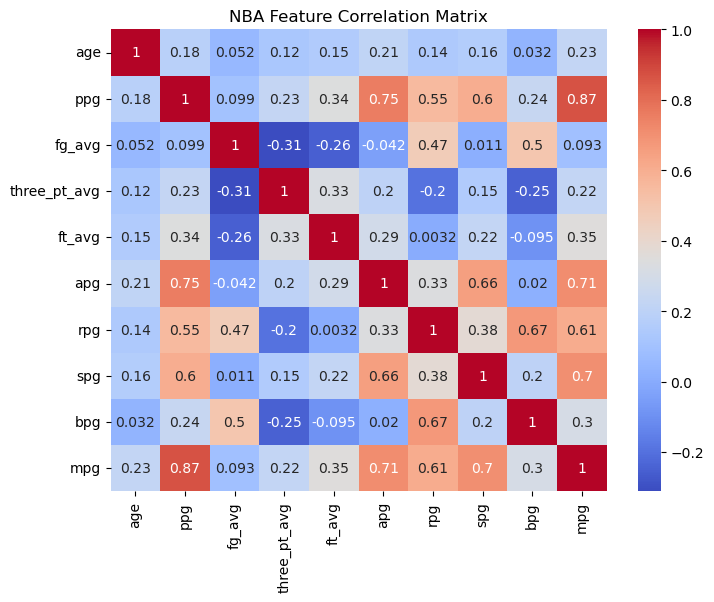

In [11]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_vector = assembler.transform(df).select("features")

matrix = Correlation.corr(df_vector, "features").collect()[0][0]
corr_matrix = matrix.toArray()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=feature_cols, yticklabels=feature_cols, cmap='coolwarm')
plt.title("NBA Feature Correlation Matrix")
plt.show()

#### 1. Strong positive correlation

The most dominant relationship in the dataset is between ``mpg`` (Minutes) and ``ppg``(Points).

#### 2. Moderate positive correlations


* ppg has a moderate relationship with ``apg`` (Assists), ``rpg`` (Rebounds), and ``spg`` (Steals). This indicates that high scorers often contribute across multiple stat categories.

* The Volume Cluster: ``mpg`` (Minutes) correlates moderately with ``rpg`` (Rebounds) and ``spg`` (Steals).

* The Physicality Link: A moderate link exists between ``fg_avg`` (Field Goal %) and ``rpg`` (Rebounds), indicating that players who shoot at a higher percentage also tend to record more rebounds.

#### 3. Weak correlations or no correlation

All remaining feature pairings.

## Distributions of Features

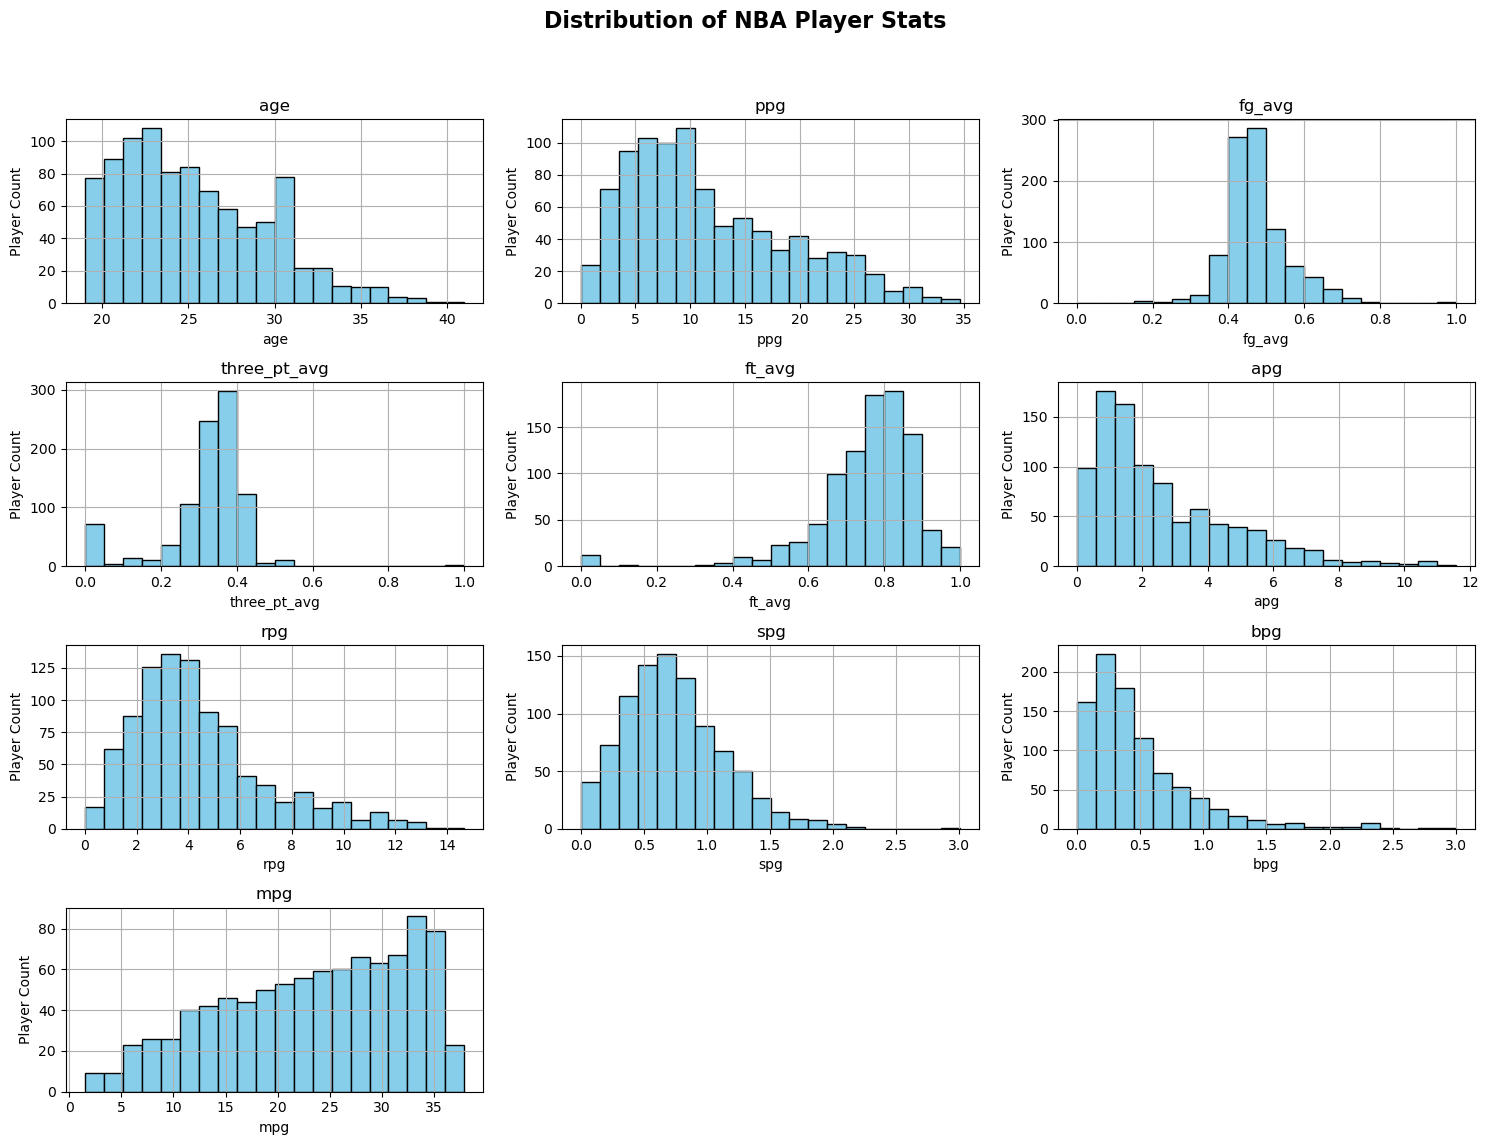

In [14]:
pdf = df.select(feature_cols).toPandas()

axes = pdf.hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')

for ax in axes.flatten():
    ax.set_xlabel(ax.get_title(), fontsize=10)
    ax.set_ylabel("Player Count", fontsize=10)

plt.suptitle("Distribution of NBA Player Stats", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* ``Age`` shows a right-skewed distribution, with most players concentrated in the early to mid-20s. The frequency declines noticeably after age 30, indicating that older players are relatively uncommon.

* ``ppg`` (Points per Game) is also strongly right-skewed. Most players average fewer than 10 points per game, while progressively fewer players score in the double digits. Only a small group reaches elite scoring levels above 25–30 points per game.

* ``fg_avg`` (Field Goal Percentage) is tightly clustered around approximately 45–55%. This suggests that shooting efficiency varies less across players than volume-based statistics such as scoring.

* ``three_pt_avg`` (Three-point percentage) shows an even narrower distribution, centered in the mid-30% range. A small number of near-zero values likely correspond to players who attempt very few three-point shots.

* ``ft_avg`` (Free Throw Percentage) is left-skewed, with most players concentrated between 70% and 90%. While poor free-throw shooters exist, the majority of players demonstrate relatively high efficiency at the line.

* ``apg`` (Assists), ``rpg`` (Rebounds), ``spg`` (Steals), and ``bpg`` (Blocks) all exhibit right-skewed distributions. Most players record smaller averages, while a few specialists account for the higher values in each category.

* ``mpg`` (Minutes per Game) increases steadily toward the higher end of the distribution. With the highest concentration between 25-35 minutes.

## Box Plots

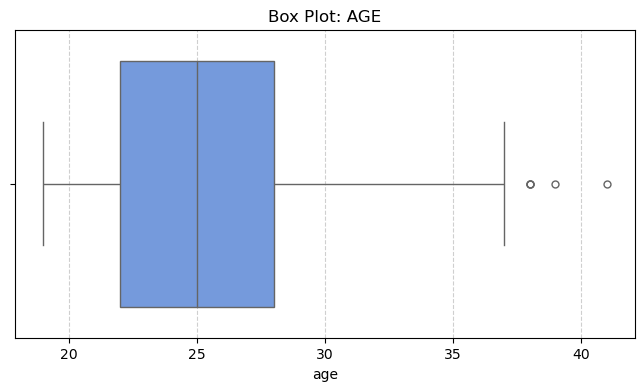

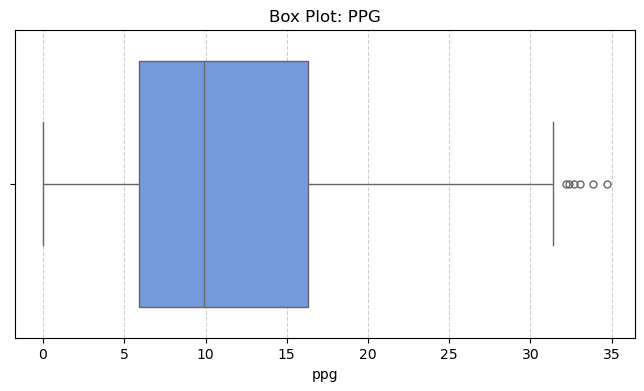

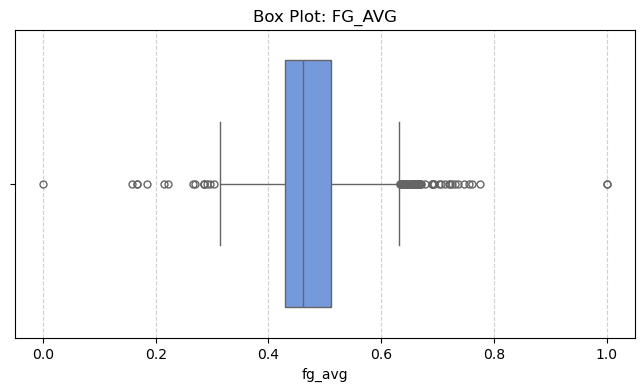

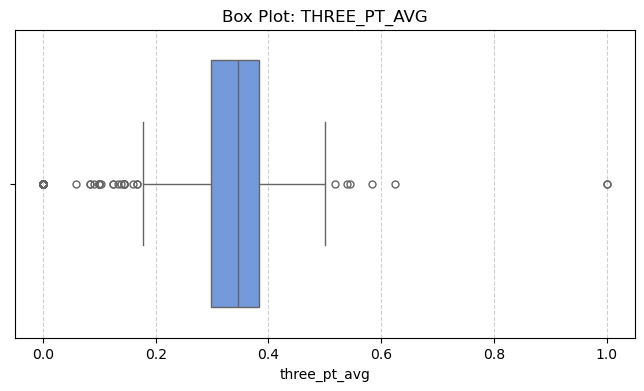

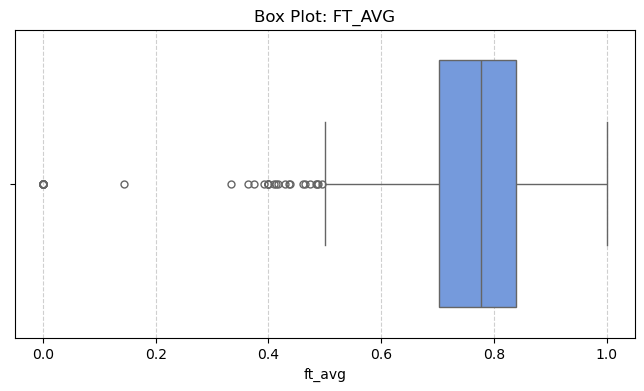

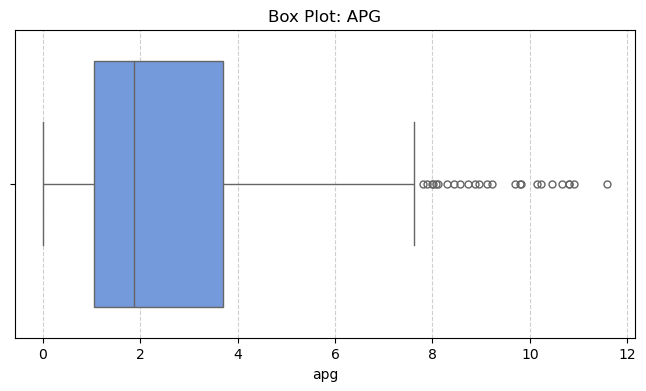

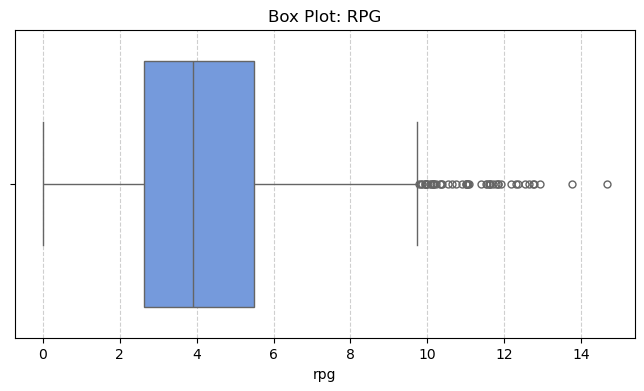

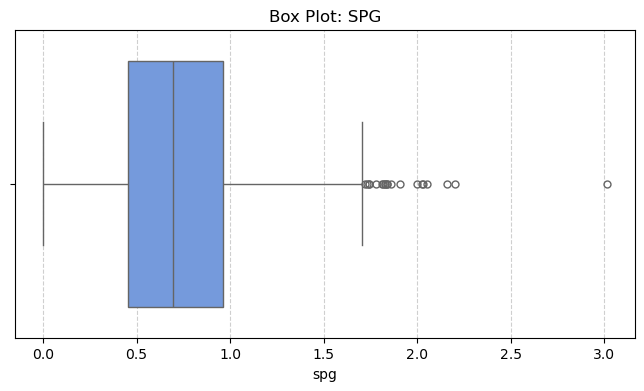

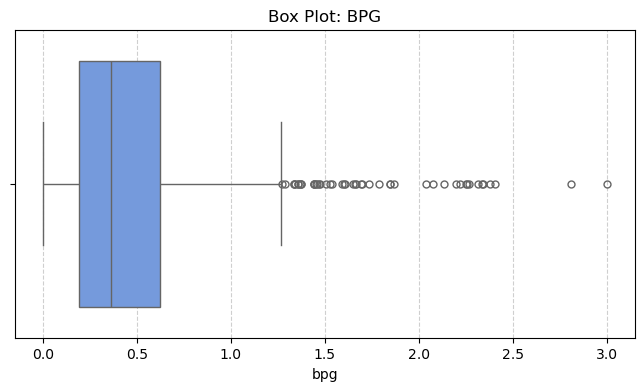

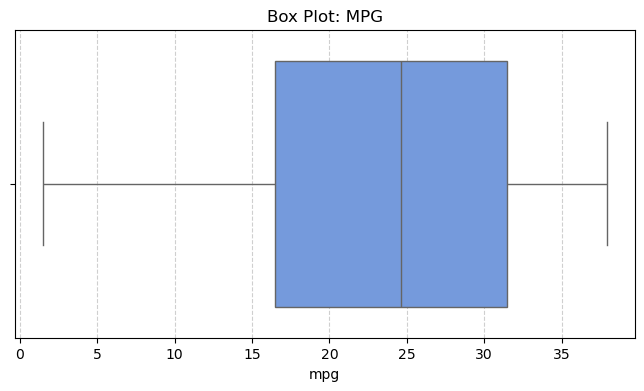

In [10]:
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=pdf[col], color='cornflowerblue', fliersize=5)
    plt.title(f"Box Plot: {col.upper()}")
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

* ``Age`` is right-skewed, with a median of approximately 25 years. Most players fall within the early 22-27 range, while a small number of outliers appear above roughly 37 years of age.

* ``ppg`` (Points per Game) is also right-skewed, with a median around 10 points. Several high-end outliers are present, including players averaging more than 30 points per game.

* ``fg_avg`` (Field Goal Percentage) shows little to no skew. The distribution is tightly clustered around a median of approximately 45%, with short and relatively even whiskers. Numerous outliers appear on both the lower and upper ends.

* ``three_pt_avg``(Three Point Percentage) follows a pattern similar to Field Goal %, with a median around 37%. The distribution is tightly concentrated, has short whiskers, and includes many outliers on both ends.

* ``ft_avg``(Free Throw Percentage) has a median near 77% and is left-skewed. While most players cluster at higher percentages, there are many lower-end outliers below 50%.

* ``apg`` (Assists per Game) is heavily right-skewed, with a median below 2 assists. A long right tail is present, with several outliers exceeding 8 assists per game.

* ``rpg`` (Rebounds per Game) is right-skewed, with a median around 4 rebounds. Numerous outliers are visible beyond 10 rebounds per game.

* ``spg`` (Steals per Game) shows slight right skew, with a median near 0.7 and several outliers above approximately 1.7 steals per game.

* ``bpg`` (Blocks per Game) is right-skewed, with a median around 0.7. A number of outliers appear at values above roughly 1.25 blocks per game.

* ``mpg`` (Minutes per Game) has a wide distribution with a median around 25 minutes. The distribution is left-skewed, indicating that fewer players average very low minutes compared to those with moderate to high playing time.
